In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar

In [3]:
# -----------------------------
# Functions for g, mu
# -----------------------------
def g_func(alpha, x, m, mu):
    """
    g = -alpha/2 * x^2 m^2
        + [ (1+m)/2 x ln((1+m)/2 x) + (1-m)/2 x ln((1-m)/2 x) + (1-x) ln(1-x) ]
        - mu x
    """
    p_plus = 0.5 * (1 + m)
    p_minus = 0.5 * (1 - m)
    p0 = 1 - x
    return (
        -0.5 * alpha * (x**2) * (m**2)
        + p_plus * x * np.log(p_plus * x)
        + p_minus * x * np.log(p_minus * x)
        + p0 * np.log(p0)
        - mu * x
    )

def Hesse_g_func(alpha, x, m):
    """
    Hesse matrix of g with respect to (x,m)
    """
    d2g_dx2 = -alpha * (m**2) + 1 / x + 1 / (1 - x)
    d2g_dx_dm = -2 * alpha * x * m + 0.5 * np.log((1 + m) / (1 - m))
    d2g_dm2 = -alpha * (x**2) + x / (1 - m**2)
    return np.array([[d2g_dx2, d2g_dx_dm], [d2g_dx_dm, d2g_dm2]])

def mu_func(alpha, x, m):
    """
    mu = -alpha x m^2
         + [ (1+m)/2 ln((1+m)/2 x) + (1-m)/2 ln((1-m)/2 x) - ln(1-x) ]
    """
    p_plus = 0.5 * (1 + m)
    p_minus = 0.5 * (1 - m)
    p0 = 1 - x
    return (
        -alpha * x * (m**2)
        + p_plus * np.log(p_plus * x)
        + p_minus * np.log(p_minus * x)
        - np.log(p0)
    )

def solve_m_branches(alpha, x, eps=1e-12):
    """
    Solve F(m,x) = tanh(alpha*x*m) - m = 0
    Return list of solutions for m,
    while alpha*x > 1 has three solutions: m=0, m=mpos, m=-mpos
     and alpha*x <= 1 has only one solution: m=0
    """
    sols = [0.0]

    # Ordered nonzero solution exists when alpha*x > 1
    if alpha * x <= 1.0 + eps:
        return sols

    def F(m):
        # G(m)=tanh(alpha*x*m)-m ; nonzero root in (0,1)
        return np.tanh(alpha * x * m) - m

    # sol nonzero root in (0,1)
    a = eps
    b = 1 - eps
    out = root_scalar(F, bracket=[a, b], method="brentq", xtol=1e-12, rtol=1e-12, maxiter=200)
    if out.converged:
        mpos = float(out.root)
        sols += [mpos, -mpos]

    return sols

In [4]:

def sample_branches(alpha, x_grid):
    """
    For each x, solve m branches, compute mu and g at the stationary point defined by mu(x,m).
    Return dict with arrays for each branch type.
    """
    pts = []
    for x in x_grid:
        ms = solve_m_branches(alpha, x)
        for m in ms:
            mu = mu_func(alpha, x, m)
            g = g_func(alpha, x, m, mu)
            g_Hesse = Hesse_g_func(alpha, x, m)
            if np.linalg.det(g_Hesse) > 0 and g_Hesse[1,1] > 0 :
                stability = True
            else:
                stability = False
            pts.append((x, m, mu, g, stability))

    # to structured arrays
    pts = np.array(pts, dtype=[
        ("x", float), ("m", float), ("mu", float), ("g", float), ('stability',int)
    ])
    return pts

In [8]:
def get_binodal_spinodal(alpha, x_res=1000):
    """
    Based on sample_branches, calculate the phase transition points for a given alpha 
    and output the corresponding x coordinates for three key points.
    """
    x_grid = np.linspace(1e-5, 1-1e-5, x_res)
    pts = sample_branches(alpha, x_grid)
    
    dis = pts[pts['m'] == 0]
    ord_pts = pts[pts['m'] > 0]
    # Filter stable ordered branch for reliable interpolation
    stable_ord = ord_pts[ord_pts['stability'] == 1]
    
    # ---------------------------------------------------------
    # 1. Spinodal for disordered branch (m=0)
    # ---------------------------------------------------------
    mu_s_dis = np.nan
    x_s_dis = np.nan
    if alpha > 1:
        # Theoretical instability for m=0 occurs at alpha*x = 1
        x_s_dis = 1.0 / alpha  
        mu_s_dis = mu_func(alpha, x_s_dis, 0)

    # ---------------------------------------------------------
    # 2. Spinodal for ordered branch
    # ---------------------------------------------------------
    mu_s_ord = np.nan
    x_s_ord = np.nan
    if len(stable_ord) > 0:
        # The point where the ordered branch loses stability (minimum mu in stable region)
        idx_min = np.argmin(stable_ord['mu'])
        mu_s_ord = stable_ord['mu'][idx_min]
        x_s_ord = stable_ord['x'][idx_min]

    # ---------------------------------------------------------
    # 3. SOLVE Binodal (energy coexistence point)
    # ---------------------------------------------------------
    mu_b = np.nan
    x_b_dis = np.nan # x coordinate of dis-phase at coexistence
    x_b_ord = np.nan # x coordinate of ord-phase at coexistence
    
    if len(stable_ord) > 1 and len(dis) > 0:
        # Interp functions for free energy g(mu)
        g_dis_interp = interp1d(dis['mu'], dis['g'], bounds_error=False)
        g_ord_interp = interp1d(stable_ord['mu'], stable_ord['g'], bounds_error=False)
        
        # Interp functions for composition x(mu)
        x_dis_mu_interp = interp1d(dis['mu'], dis['x'], bounds_error=False)
        x_ord_mu_interp = interp1d(stable_ord['mu'], stable_ord['x'], bounds_error=False)
        
        def dg_func(mu_val):
            return g_dis_interp(mu_val) - g_ord_interp(mu_val)
        
        # Find overlapping mu range of stable branches
        mu_min = max(dis['mu'].min(), stable_ord['mu'].min())
        mu_max = min(dis['mu'].max(), stable_ord['mu'].max())
        
        if mu_max > mu_min:
            try:
                # Solve for g_dis(mu) = g_ord(mu)
                sol = root_scalar(dg_func, bracket=[mu_min, mu_max], method='brentq')
                mu_b = sol.root
                # Retrieve corresponding x coordinates via interpolation
                x_b_dis = float(x_dis_mu_interp(mu_b))
                x_b_ord = float(x_ord_mu_interp(mu_b))
            except:
                pass

    return {
        'alpha': alpha,
        'mu_binodal': mu_b,
        'x_binodal_dis': x_b_dis,
        'x_binodal_ord': x_b_ord,
        'mu_spinodal_dis': mu_s_dis,
        'x_spinodal_dis': x_s_dis,
        'mu_spinodal_ord': mu_s_ord,
        'x_spinodal_ord': x_s_ord
    }

# Example call
# print(get_binodal_spinodal(9.0))

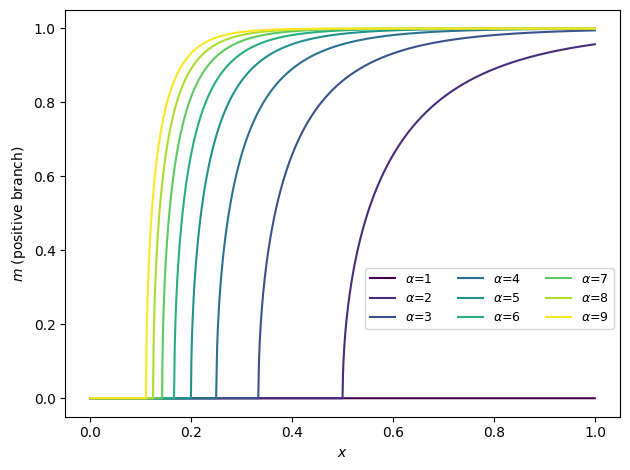

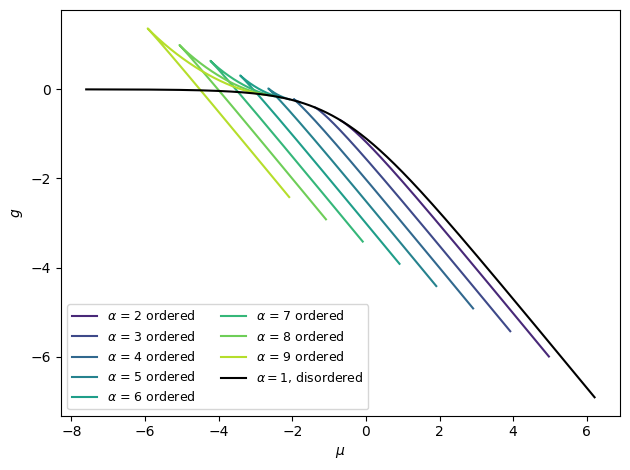

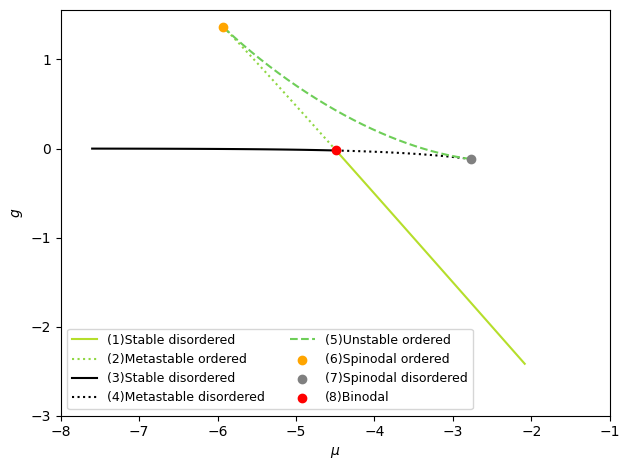

In [9]:

# -----------------------------
def main():
    # x grid avoid 0 and 1
    x_grid = np.linspace(1e-3, 1 - 1e-3, 2000)

    alphas = range(1, 10)

    # ---- (i) m vs x for alpha=1..9 ----
    plt.figure()
    for alpha in alphas:
        # for each x, get ordered solution m>0 if exists, else 0
        m_plot = np.zeros_like(x_grid)
        for i, x in enumerate(x_grid):
            ms = solve_m_branches(alpha, x)
            # pick positive ordered if exists else 0
            mpos = max(ms)
            m_plot[i] = mpos
        plt.plot(x_grid, m_plot, label=f"$\\alpha$={alpha}", color=plt.cm.viridis((alpha-1)/8))

    plt.xlabel("$x$")
    plt.ylabel("$m$ (positive branch)")
    plt.legend(ncol=3, fontsize=9, bbox_to_anchor=(1,0.2), loc='lower right')
    plt.tight_layout()

    # ---- (ii) g vs mu for alpha=1..9 ----
    plt.figure()
    for alpha in alphas:
        pts = sample_branches(alpha, x_grid)

        # distinguish disordered vs ordered branches by m=0 vs m>0
        dis = pts[np.isclose(pts["m"], 0.0, atol=1e-5)]
        ord = pts[pts["m"] > 1e-5]

        if len(ord) > 0:
            plt.plot(ord["mu"], ord["g"], '-', color=plt.cm.viridis((alpha-1)/9), label=f"$\\alpha$ = {alpha} ordered")
    
    # ordered branch, as well as the alpha=1
    plt.plot(dis["mu"], dis["g"], '-', color='k', label=f"$\\alpha=1$, disordered")

    plt.xlabel("$\\mu$")
    plt.ylabel("$g$")
    plt.legend(fontsize=9, ncol=2)
    plt.tight_layout()

    # ---- (iii) alpha=9 labeled plot ----
    alpha = 9
    pts = sample_branches(alpha, x_grid)
        
    # distinguish disordered vs ordered branches by m=0 vs m>0
    dis = pts[np.isclose(pts["m"], 0.0, atol=1e-5)]
    ord = pts[pts["m"] > 1e-5]

    pts = sample_branches(alpha, x_grid)

    dis = pts[np.isclose(pts["m"], 0.0, atol=1e-5)]
    ord = pts[pts["m"] > 1e-5]

    get_binodal_spinodal(alpha, x_res=1000)
    mu_star = get_binodal_spinodal(alpha, x_res=1000)['mu_binodal']
    g_star = np.nan
    if not np.isnan(mu_star):
        g_star = interp1d(dis['mu'], dis['g'], bounds_error=False)(mu_star)

    # go over stability branch and label metastable, all ord[ord["stability"]==1 & ord["g"] > g_star] are metastable, give stability=2 for metastable for plotting
    ord["stability"] = np.where((ord["stability"]==1) & (ord["g"] > g_star), 2, ord["stability"])
    # all dis[dis["stability"]==1 & dis["mu"] > mu_star] are metastable, give stability=2 for plotting
    dis["stability"] = np.where((dis["stability"]==1) & (dis["mu"] > mu_star), 2, dis["stability"])
    
    # print(ord[ord["stability"]==2])
    # print(dis[dis["stability"]==2])

    plt.figure()
    # stability is 1, solid line; stability is 0, dashed line;
    plt.plot(ord[ord["stability"]==1]["mu"], ord[ord["stability"]==1]["g"], '-', color=plt.cm.viridis((alpha-1)/9), label=f"(1)Stable disordered", zorder=2)
    plt.plot(ord[ord["stability"]==2]["mu"], ord[ord["stability"]==2]["g"], ':', color=plt.cm.viridis((alpha-1.5)/9), label=f"(2)Metastable ordered", zorder=2)
    plt.plot(dis[dis["stability"]==1]["mu"], dis[dis["stability"]==1]["g"], '-', color='k', label=f"(3)Stable disordered", zorder=1)
    plt.plot(dis[dis["stability"]==2]["mu"], dis[dis["stability"]==2]["g"], ':', color='k', label=f"(4)Metastable disordered", zorder=1)
    plt.plot(ord[ord["stability"]==0]["mu"], ord[ord["stability"]==0]["g"], '--', color=plt.cm.viridis((alpha-2)/9), label=f"(5)Unstable ordered", zorder=2)
   # plt.plot(dis[dis["stability"]==0]["mu"], dis[dis["stability"]==0]["g"], '--', color='k', label=f"(5)Unstable disordered", zorder=1)

    # scatter the spinodal points where stability changes from 0 to 2
    spin_ord = ord[ord["stability"]==0]
    spin_ord = spin_ord[np.roll(ord["stability"],-1)[ord["stability"]==0]==2]
    # scatter the spinodal points where stability changes from 2 to 0
    spin_dis = dis[dis["stability"]==2]
    spin_dis = spin_dis[np.roll(dis["stability"],-1)[dis["stability"]==2]==0]
    plt.scatter(spin_ord["mu"], spin_ord["g"], color='orange', label=f"(6)Spinodal ordered", zorder=3)
    plt.scatter(spin_dis["mu"], spin_dis["g"], color='gray', label=f"(7)Spinodal disordered", zorder=3)

    
    # scatter the intersection point
    plt.scatter([mu_star], [g_star], color='red', label=f"(8)Binodal", zorder=3)

    plt.xlabel("$\\mu$")
    plt.ylabel("$g$")
    # plt.yscale("log")
    # plt.ylim(1e-10, 1e-1)
    plt.xlim(-8,-1)
    plt.ylim(-3,)
    plt.legend(fontsize=9, ncol=2)
    plt.tight_layout()


    plt.show()

if __name__ == "__main__":
    main()

In [ ]:
alphas = np.linspace(1.0, 9.0, 300)

# Separate storage for second-order and first-order data points
alpha_2nd, mu_lambda = [], []
alpha_1st, mu_binodal, mu_spin_dis, mu_spin_ord = [], [], [], []

for a in alphas:
    res = get_binodal_spinodal(a, x_res=25000)
    print(f"alpha={a:.2f}, binodal={res['mu_binodal']:.4f}, spinodal_dis={res['mu_spinodal_dis']:.4f}, spinodal_ord={res['mu_spinodal_ord']:.4f}")
    m_b = res['mu_binodal']
    m_s_dis = res['mu_spinodal_dis'] 
    m_s_ord = res['mu_spinodal_ord'] 

    if not np.isnan(m_b) and not np.isclose(m_b, m_s_dis, atol=1e-3):
        alpha_1st.append(a)
        mu_binodal.append(m_b)
        mu_spin_dis.append(m_s_dis)
        mu_spin_ord.append(m_s_ord)
    else:
        if not np.isnan(m_s_dis):
            alpha_2nd.append(a)
            mu_lambda.append(m_s_dis)


alpha=1.00, binodal=nan, spinodal_dis=nan, spinodal_ord=nan
alpha=1.03, binodal=2.9282, spinodal_dis=2.9279, spinodal_ord=2.9282
alpha=1.05, binodal=2.2351, spinodal_dis=2.2347, spinodal_ord=2.2351
alpha=1.08, binodal=1.8294, spinodal_dis=1.8292, spinodal_ord=1.8294
alpha=1.11, binodal=1.5418, spinodal_dis=1.5416, spinodal_ord=1.5418
alpha=1.13, binodal=1.3186, spinodal_dis=1.3184, spinodal_ord=1.3186
alpha=1.16, binodal=1.1363, spinodal_dis=1.1361, spinodal_ord=1.1363
alpha=1.19, binodal=0.9820, spinodal_dis=0.9819, spinodal_ord=0.9820
alpha=1.21, binodal=0.8485, spinodal_dis=0.8484, spinodal_ord=0.8485
alpha=1.24, binodal=0.7307, spinodal_dis=0.7306, spinodal_ord=0.7307
alpha=1.27, binodal=0.6254, spinodal_dis=0.6253, spinodal_ord=0.6254
alpha=1.29, binodal=0.5300, spinodal_dis=0.5300, spinodal_ord=0.5300
alpha=1.32, binodal=0.4430, spinodal_dis=0.4429, spinodal_ord=0.4430
alpha=1.35, binodal=0.3629, spinodal_dis=0.3629, spinodal_ord=0.3629
alpha=1.37, binodal=0.2888, spinodal_dis=0.

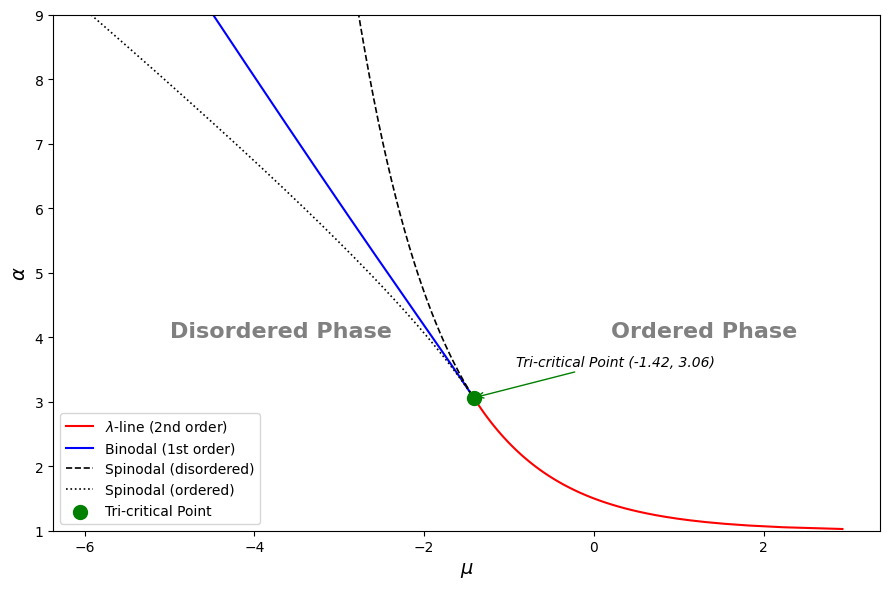

In [ ]:
# -----Plotting the phase diagram in mu-alpha space -----
plt.figure(figsize=(9, 6))

plt.plot(mu_lambda, alpha_2nd, linestyle='-', linewidth=1.5, color='red',
         label=r'$\lambda$-line (2nd order)')

plt.plot(mu_binodal, alpha_1st, linestyle='-', linewidth=1.5, color='blue',
         label='Binodal (1st order)')
    
plt.plot(mu_spin_dis, alpha_1st, color='black', linestyle='--', linewidth=1.2, 
         label='Spinodal (disordered)')
plt.plot(mu_spin_ord, alpha_1st, color='black', linestyle=':', linewidth=1.2, 
         label='Spinodal (ordered)')

if len(alpha_1st) > 0 and len(alpha_2nd) > 0:
    tcp_a = alpha_2nd[-1]
    tcp_m = mu_lambda[-1]
    plt.scatter(tcp_m, tcp_a, color='green', s=100, zorder=5, label='Tri-critical Point')
    plt.annotate(f'Tri-critical Point ({tcp_m:.2f}, {tcp_a:.2f})', xy=(tcp_m, tcp_a), 
                 xytext=(tcp_m+0.5, tcp_a+0.5),
                 fontstyle='italic',
                 arrowprops=dict(arrowstyle='->', color='green'))

plt.text(0.2, 4, 'Ordered Phase', fontsize=16, fontweight='bold', color='gray')
plt.text(-5, 4, 'Disordered Phase', fontsize=16, fontweight='bold', color='gray')

plt.xlabel(r'$\mu$', fontsize=14)  
plt.ylabel(r'$\alpha$', fontsize=14) 
# plt.title(r'Phase Diagram in $\mu-\alpha$ space', fontsize=16)

plt.ylim(1, 9) 
# plt.xlim(-10, 5) 

plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# Data Generation & Processing
# ---------------------------------------------------------
alphas = np.linspace(1.1, 9.0, 200) 
results = []

for a in alphas:
    res = get_binodal_spinodal(a, x_res=10000)
    print(f"alpha={a:.2f}, binodal={res['mu_binodal']:.4f}, spinodal_dis={res['mu_spinodal_dis']:.4f}, spinodal_ord={res['mu_spinodal_ord']:.4f}, x_binodal_dis={res['x_binodal_dis']:.4f}, x_binodal_ord={res['x_binodal_ord']:.4f}, x_spinodal_dis={res['x_spinodal_dis']:.4f}, x_spinodal_ord={res['x_spinodal_ord']:.4f}")
    results.append(res)



alpha=1.10, binodal=1.6104, spinodal_dis=1.6094, spinodal_ord=1.6104, x_binodal_dis=0.9092, x_binodal_ord=0.9092, x_spinodal_dis=0.9091, x_spinodal_ord=0.9092
alpha=1.14, binodal=1.2756, spinodal_dis=1.2751, spinodal_ord=1.2755, x_binodal_dis=0.8775, x_binodal_ord=0.8775, x_spinodal_dis=0.8774, x_spinodal_ord=0.8775
alpha=1.18, binodal=1.0255, spinodal_dis=1.0250, spinodal_ord=1.0255, x_binodal_dis=0.8480, x_binodal_ord=0.8480, x_spinodal_dis=0.8479, x_spinodal_ord=0.8480
alpha=1.22, binodal=0.8256, spinodal_dis=0.8251, spinodal_ord=0.8256, x_binodal_dis=0.8204, x_binodal_ord=0.8204, x_spinodal_dis=0.8203, x_spinodal_ord=0.8204
alpha=1.26, binodal=0.6589, spinodal_dis=0.6586, spinodal_ord=0.6588, x_binodal_dis=0.7945, x_binodal_ord=0.7945, x_spinodal_dis=0.7944, x_spinodal_ord=0.7945
alpha=1.30, binodal=0.5161, spinodal_dis=0.5159, spinodal_ord=0.5160, x_binodal_dis=0.7702, x_binodal_ord=0.7702, x_spinodal_dis=0.7701, x_spinodal_ord=0.7702
alpha=1.34, binodal=0.3913, spinodal_dis=0.391

In [ ]:
# inverse of alpha
inv_alpha = 1.0 / alphas

x_bin_dis = np.array([1 - r['x_binodal_dis'] for r in results])
x_bin_ord = np.array([1 - r['x_binodal_ord'] for r in results])
x_spin_dis = np.array([1 - r['x_spinodal_dis'] for r in results])
x_spin_ord = np.array([1 - r['x_spinodal_ord'] for r in results])

# new thershold for x
separation_threshold = 1e-3 
first_order_mask = np.abs(x_bin_dis - x_bin_ord) > separation_threshold

if any(first_order_mask):
    tcp_idx = np.where(first_order_mask)[0][0]
else:
    tcp_idx = len(alphas)

final_first_order_mask = np.zeros_like(alphas, dtype=bool)
final_first_order_mask[tcp_idx:] = True
lambda_mask = ~final_first_order_mask

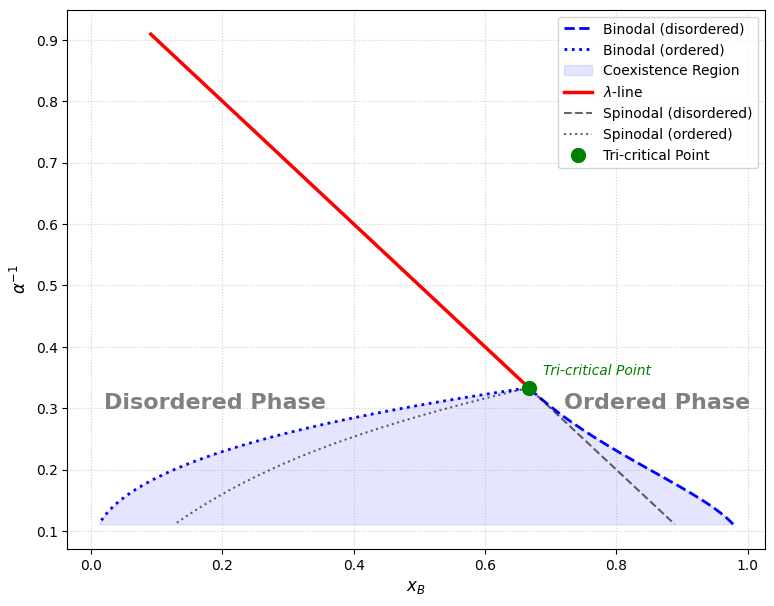

In [ ]:

# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------
plt.figure(figsize=(9, 7))

# Plot Coexistence Region (Binodal)
plt.plot(x_bin_dis[first_order_mask], inv_alpha[first_order_mask], 'b--', linewidth=2, label='Binodal (disordered)')
plt.plot(x_bin_ord[first_order_mask], inv_alpha[first_order_mask], 'b:', linewidth=2, label='Binodal (ordered)')

# Fill the coexistence region
plt.fill_betweenx(inv_alpha[first_order_mask], x_bin_ord[first_order_mask], x_bin_dis[first_order_mask], 
                 color='blue', alpha=0.1, label='Coexistence Region')

# Plot Lambda Line (2nd Order)
# The lambda line is where x = 1/alpha, so 1-x = 1 - 1/alpha
lambda_mask = ~first_order_mask & ~np.isnan(x_spin_dis)
plt.plot(x_spin_dis[lambda_mask], inv_alpha[lambda_mask], 'r-', linewidth=2.5, label=r'$\lambda$-line')

# Plot Spinodals (1st Order region)
plt.plot(x_spin_dis[first_order_mask], inv_alpha[first_order_mask], 'k--', alpha=0.6, label='Spinodal (disordered)')
plt.plot(x_spin_ord[first_order_mask], inv_alpha[first_order_mask], 'k:', alpha=0.6, label='Spinodal (ordered)')

# Mark TCP
if any(first_order_mask):
    tcp_idx = np.where(first_order_mask)[0][0]
    plt.plot(x_bin_dis[tcp_idx], inv_alpha[tcp_idx], 'go', markersize=10, label='Tri-critical Point')
    plt.annotate('Tri-critical Point', xy=(x_bin_dis[tcp_idx], inv_alpha[tcp_idx]), xytext=(+10, +10),
                 textcoords='offset points', fontstyle='italic', color='green')

plt.text(0.02, 0.3, 'Ordered Phase', fontsize=16, fontweight='bold', color='gray')
plt.text(0.72, 0.3, 'Disordered Phase', fontsize=16, fontweight='bold', color='gray')

# Formatting
plt.xlabel(r'$x_B$', fontsize=12)
plt.ylabel(r'$\alpha^{-1}$', fontsize=12)
# plt.title(r'Phase Diagram in $\alpha^{-1}$ vs $x_B$ Space', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
# plt.gca().invert_xaxis() # Optional: invert if you want 1-x=0 (pure) on the right
plt.show()